# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [17]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

In [18]:
# Recuperando o DataFrame para exportar
    # Criando o DataFrame inicial
df_genes = pd.read_csv('df_genes.csv', index_col='Unnamed: 0')
df_genes['id_entrez'] = [
    "NM_003140.3",
    "NM_004066.3",
    "XM_842234.1",
    "NM_004448.4",
    "XM_067079949.1"
]

df_genes['id_protein'] = [
    "NP_003131.1",
    "NP_004057.1",
    "XP_847327.1",
    "NP_004439.2",
    "XP_066936050.1"
]

descr_gene = {}
for gene in df_genes.index:
    caminho = f"./{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
df = pd.DataFrame.from_dict(descr_gene, orient='index')

    # Adicionando o DataFrame Final
fas_gene1 = {}
for aa in df.iloc[0,2]:
    fas_gene1[aa] = df.iloc[0,2].count(aa)

fas_gene2 = {}
for aa in df.iloc[0,2]:
    fas_gene2[aa] = df.iloc[1,2].count(aa)

fas_gene3 = {}
for aa in df.iloc[0,2]:
    fas_gene3[aa] = df.iloc[2,2].count(aa)

fas_gene4 = {}
for aa in df.iloc[0,2]:
    fas_gene4[aa] = df.iloc[3,2].count(aa)

fas_gene5 = {}
for aa in df.iloc[0,2]:
    fas_gene5[aa] = df.iloc[4,2].count(aa)

dic_genes = {
    "SRY": fas_gene1,
    "Cetn-1": fas_gene2,
    "PFR2": fas_gene3,
    "HER2": fas_gene4,
    "GFP": fas_gene5
}

df_aa = pd.DataFrame(dic_genes).sort_index()

    # Trocando o código do aminoácido pelo nome extenso
df_aa.index = ["Alanina", "Cisteína", "Aspartato", "Glutamato", "Fenilalanina",
               "Glicina", "Histidina", "Isoleucina", "Lisina", "Leucina",
               "Metionina", "Asparagina", "Prolina", "Glutamina", "Arginina",
               "Serina", "Treonina", "Valina", "Triptofano", "Tirosina"]
df_aa

,SRY,Cetn-1,PFR2,HER2,GFP
Alanina,15,12,53,83,17
Cisteína,6,0,7,59,5
Aspartato,9,16,34,65,13
Glutamato,12,24,79,77,13
Fenilalanina,5,10,14,35,10
Glicina,4,11,18,101,22
Histidina,5,0,18,35,8
Isoleucina,4,7,29,44,14
Lisina,15,21,59,39,16
Leucina,16,13,59,138,17


In [19]:
# Exportando o DataFrame
df_aa.to_csv('df_aa.csv')

In [20]:
# Importando o DataFrame
df_aa = pd.read_csv('df_aa.csv', index_col='Unnamed: 0')
df_aa

,SRY,Cetn-1,PFR2,HER2,GFP
Alanina,15,12,53,83,17
Cisteína,6,0,7,59,5
Aspartato,9,16,34,65,13
Glutamato,12,24,79,77,13
Fenilalanina,5,10,14,35,10
Glicina,4,11,18,101,22
Histidina,5,0,18,35,8
Isoleucina,4,7,29,44,14
Lisina,15,21,59,39,16
Leucina,16,13,59,138,17


Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [92]:
def medidor_tendcent(obj:list | tuple | pd.Series) -> list:
    '''
    Função para pegar um objeto (obj) composto unidimensional (lista, tupla ou pandas.Series)
    e retornar uma lista contendo as medidas centrais: primeiro, a média; segundo, a mediana;
    teceiro, a moda (que pode ser uma lista se houver mais de um valor)
    '''
    resultado = [
        st.mean(obj),
        st.median(obj),
        st.multimode(obj)
    ]
    return resultado

In [93]:
# Valor da média, mediana e moda da Serina nos genes analisados, respectivamente:
medidor_tendcent(obj=df_aa.loc["Serina"])

[28, 21, [21, 9, 26, 73, 11]]

In [95]:
# Valor da média, mediana e moda do terceiro gene (PFR2), respectivamente:
medidor_tendcent(obj=df_aa["PFR2"])

[30, 24.5, [18, 59]]

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [96]:
def medidor_ampl(obj: list | tuple | pd.Series) -> int:
    '''
    Função que recebe um objeto (obj) composto unidimensional (lista, tupla ou pandas Series)
    e retorna a amplitude
    '''
    resultado = max(obj) - min(obj)
    return resultado

In [97]:
medidor_ampl(obj=df_aa.loc["Isoleucina"])

40

In [98]:
medidor_ampl(obj=df_aa["GFP"])

21

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [154]:
def medidor_quar(obj: list | tuple | pd.Series) -> list:
    '''
    Função para retornar de um objeto composto unidimensional (lista, tupla ou pandas.Series)
    o valor de Q1, Q2 e Q3, respectivamente
    '''
    quantil_1 = np.quantile(obj, [0.25])
    quantil_2 = np.quantile(obj, [0.5])
    quantil_3 = np.quantile(obj, [0.75])
    resultado = float(quantil_1[0]), float(quantil_2[0]), float(quantil_3[0])
    return resultado

In [155]:
# Q1, Q2 e Q3 da Metionina, respectivamente
medidor_quar(obj=df_aa.loc["Metionina"])

(8.0, 9.0, 19.0)

In [156]:
# Q1, Q2 e Q3 do primeiro gene (SRY), respectivamente
medidor_quar(obj=df_aa["SRY"])

(5.75, 9.0, 14.25)

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [159]:
def medidor_iquar(obj: list | tuple | pd.Series) -> list:
    '''
    Função para retornar de um objeto composto unidimensional (lista, tupla ou pandas.Series)
    o intervalo interquartil (Q3 - Q1)
    '''
    quantil_1 = np.quantile(obj, [0.25])
    quantil_3 = np.quantile(obj, [0.75])
    resultado = float(quantil_3[0]) - float(quantil_1[0])
    return resultado

In [164]:
# Intervalo interquartil do Ácido Glutâmico (Glutamato)
medidor_iquar(obj=df_aa.loc["Glutamato"])

64.0

In [166]:
# Intervalo interquartil do penúltimo gene (HER2)
medidor_iquar(obj=df_aa["HER2"])

40.5

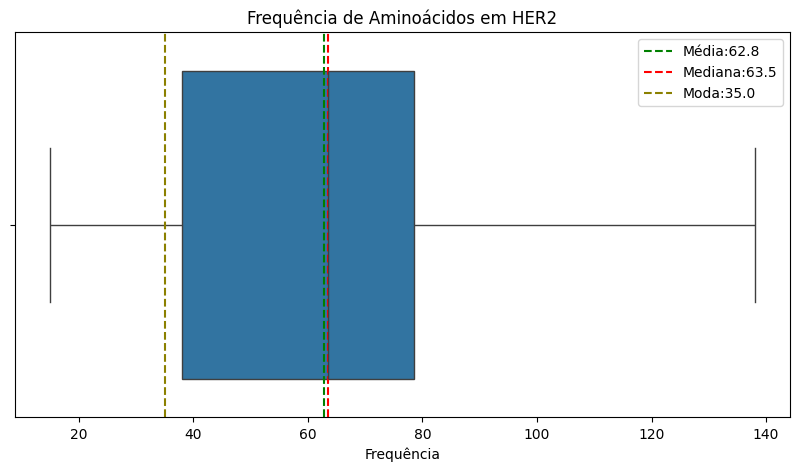

In [200]:
med_cent = medidor_tendcent(obj=df_aa["HER2"])
moda = med_cent[2]

plt.figure(figsize=(10,5))
sns.boxplot(
    data = df_aa,
    x = "HER2"
)
plt.axvline(med_cent[0], color="green", linestyle="--", label=f'Média:{med_cent[0]:.1f}')
plt.axvline(med_cent[1], color="red", linestyle="--", label=f'Mediana:{med_cent[1]:.1f}')
plt.axvline(moda[0], color="#8B8000", linestyle="--", label=f'Moda:{moda[0]:.1f}')
plt.legend()
plt.title("Frequência de Aminoácidos em HER2")
plt.xlabel("Frequência")
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?